# Nike DCF: learn the valuation one calculation at a time

**Research window: January 1, 2019 to September 15, 2026. Valuation timestamp: September 15, 2026, 4:00 p.m. New York time.**

Equity research asks what a business can earn, what those earnings turn into as cash,
and what a shareholder should pay for that cash. A discounted cash flow (DCF) model
estimates operating-business value from future cash available to debt and equity
investors, then reconciles that value to common equity.

Read the Markdown immediately before each code cell. Each step explains its formula,
purpose, and choices. An **ASSUMPTION** block means an analyst judgement, not a company-reported fact.
All money is in absolute US dollars, shares in individual shares, and rates in decimal
fractions: `0.02` means 2%. Display charts convert dollars into billions only for readability.

The path is: financial statements -> historical drivers -> operating forecasts -> FCFF
-> WACC -> terminal value -> equity value per share -> sensitivity -> small sentiment overlay.
There are three forecast scenarios (bear, base, bull), and no separate news forecast scenario.
The unadjusted DCF remains visible at the final step.

This teaches a reproducible valuation workflow. Business judgement also requires reading
the filings, evaluating products and demand, and revising assumptions when evidence changes.
The output is an approximate value **as of the valuation date**, not a promised 12-month price.

## Sources and preparation

Run `preprocess_all.ipynb` first. This notebook reads existing files and never fetches SEC filings.
SEC financial data were obtained through **sec2md** and retain filing URLs and Markdown line numbers.

| Input | Local file | Source and use |
|---|---|---|
| Historical operations | `data/preprocess/historical_annual.csv` | [SEC EDGAR](https://www.sec.gov/search-filings), three available fiscal-year anchors |
| Balance sheet | `data/preprocess/latest_balance.csv` | SEC, May 31, 2026 bridge and working capital |
| Fact provenance | `data/preprocess/clean_facts.csv` | SEC facts with filing dates, units and source lines |
| Debt fair value | `data/raw/sec_filings/NKE/10-K_2026-05-31_*.md` | Existing sec2md annual-report note |
| Discount-rate inputs | `data/preprocess/wacc_reference.csv` | [Treasury](https://home.treasury.gov/resource-center/data-chart-center/interest-rates), [Damodaran ERP](https://pages.stern.nyu.edu/adamodar/New_Home_Page/home.htm), [industry beta](https://pages.stern.nyu.edu/adamodar/New_Home_Page/datafile/Betas.html) |
| Comparison price | Recorded project observation: $36.22 on September 15, 2026 | [Yahoo historical prices](https://finance.yahoo.com/quote/NKE/history/); cached project observation, not a live quote |
| NKE price history | `data/raw/prices/nke.csv` | Yahoo Finance daily adjusted closes; used for the trailing price path in the overall target chart |
| News | `data/raw/news/nike_news.csv` | Monthly searches via [news search API](https://serpapi.com/news-results); individual article URLs retained |
| Text scoring | VADER 3.3.2 | [Original implementation](https://github.com/cjhutto/vaderSentiment), a general-language lexicon with rules for negation and emphasis |

Method references: [Damodaran FCFF definitions](https://pages.stern.nyu.edu/~adamodar/New_Home_Page/definitions.html)
and [terminal reinvestment](https://pages.stern.nyu.edu/~adamodar/New_Home_Page/AppldCF/derivn/ch12deriv.html).
Install the notebook dependencies with `python -m pip install -r data_extraction/requirements_dcf.txt`
in the same Python environment as the notebook kernel.

**Data boundaries:** source series can have shorter coverage than the research window.
The three-year operating history is a forecast anchor; the full news window remains available.
Publication dates are checked, but historical files retrieved later are not a certified point-in-time database.
Forecasts extend beyond 2026 because DCF values future cash flows; those future values are assumptions.

## Read the three statements together

The **income statement** records revenue and expenses over a period, using accrual accounting.
EBIT is earnings before interest and taxes; EBITDA adds back depreciation and amortization.
Net income is after financing costs and taxes and therefore belongs further down the equity bridge.

The **balance sheet** records assets, liabilities and shareholders' equity at a date.
Receivables represent sales awaiting payment; inventory represents stock awaiting sale;
payables represent supplier bills awaiting payment. Growing these balances changes cash needs.

The **cash-flow statement** explains changes in cash through operations, investing and financing.
Depreciation reduces accounting profit without a current cash payment. Capital expenditure
(capex) consumes cash when assets are purchased. Dividends and buybacks distribute equity cash;
they are not operating costs to subtract again from unlevered cash flow.

Our FCFF keeps stock-based compensation in operating expenses. We do not add it back as free money.
This is a simplified treatment of its economic cost; a full dilution analysis would model awards,
options and repurchases separately.

## Step 1: Load the tools

**Formula or operation:** Import numerical, table, plotting and sentiment libraries.

**Why?** These tools provide the arithmetic and charts used below. VADER runs locally with its packaged lexicon.

In [1]:
from pathlib import Path
import importlib
import json
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Circle, Wedge
from IPython.display import display
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


## Step 2: Set dates and output location

**Formula or operation:** News timestamp <= valuation timestamp.

**Why?** A closing-price comparison should exclude news released after that close. Store this rewritten model in its own results directory so older calculations cannot be mistaken for these outputs.

In [2]:
root = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'data/preprocess/historical_annual.csv').exists())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import constants as chart_constants
importlib.reload(chart_constants)
from constants import (BACKGROUND, PANEL_BACKGROUND, TEXT, MUTED_TEXT, GRID,
                          REFERENCE, NIKE, COMPANY_COLORS, CHANNEL_COLORS,
                          LOGO_FILES, LOGO_DISPLAY_PX, SCENARIO_COLORS,
                          VALUATION_COLORS, HEATMAP_COLORS, SIGNAL_COLORS)

prepared = root / 'data/preprocess'
output = root / 'data/results/dcf_learning'
logo_dir = root / 'data/logo'
analysis_start = pd.Timestamp('2019-01-01', tz='UTC')
valuation_time = pd.Timestamp('2026-09-15 16:00', tz='America/New_York')
cutoff_utc = valuation_time.tz_convert('UTC')
valuation_date = pd.Timestamp(valuation_time.date())
fiscal_base = pd.Timestamp('2026-05-31')

assert (logo_dir / LOGO_FILES['Nike']).exists()
plt.rcParams.update({
    'figure.facecolor': BACKGROUND,
    'savefig.facecolor': BACKGROUND,
    'axes.facecolor': PANEL_BACKGROUND,
    'axes.edgecolor': GRID,
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,
    'xtick.color': MUTED_TEXT,
    'ytick.color': MUTED_TEXT,
    'text.color': TEXT,
    'legend.labelcolor': TEXT,
    'font.size': 10,
    'axes.titleweight': 'bold',
})


def style_axes(ax, grid_axis='y'):
    ax.set_facecolor(PANEL_BACKGROUND)
    ax.grid(axis=grid_axis, color=GRID, linewidth=.8, alpha=.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.tick_params(colors=MUTED_TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)


def nike_logo_array():
    image = plt.imread(logo_dir / LOGO_FILES['Nike'])
    alpha = image[..., 3] if image.shape[-1] == 4 else np.ones(image.shape[:2])
    visible = np.argwhere(alpha > .02)
    y0, x0 = visible.min(axis=0)
    y1, x1 = visible.max(axis=0) + 1
    alpha = alpha[y0:y1, x0:x1]
    stride = max(1, int(np.ceil(max(alpha.shape) / 160)))
    alpha = alpha[::stride, ::stride]
    tinted = np.zeros((*alpha.shape, 4), dtype=float)
    tinted[..., :3] = to_rgb(NIKE)
    tinted[..., 3] = alpha
    return tinted



## Step 3: Load Nike's prepared statements

**Formula or operation:** Select ticker = NKE; sort fiscal periods chronologically.

**Why?** We work on copies so the raw and prepared data remain intact. A fiscal year is the company's accounting year; Nike's year ends in May.

In [3]:
all_history = pd.read_csv(prepared / 'historical_annual.csv')
history = all_history.loc[all_history.ticker.eq('NKE')].copy()
history['period_end'] = pd.to_datetime(history.period_end)
history = history.sort_values('period_end').reset_index(drop=True)
balances = pd.read_csv(prepared / 'latest_balance.csv')
nike_balance = balances.loc[balances.ticker.eq('NKE')].copy()
assert len(nike_balance) == 1, 'Expected one latest Nike balance sheet'
balance = nike_balance.iloc[0]
macro = pd.read_csv(prepared / 'wacc_reference.csv')
audit = pd.read_csv(prepared / 'clean_facts.csv')

## Step 4: Check dates, units and completeness

**Formula or operation:** One row per fiscal year; all required amounts finite; all actuals precede valuation.

**Why?** Missing values must not silently become zeros. A thousand-versus-million unit error can overwhelm every later valuation decision.

In [4]:
required = ['revenue', 'gross_profit', 'selling_general_admin', 'operating_income',
            'depreciation_amortization', 'capital_expenditures', 'operating_nwc_proxy']
assert history.period_end.is_unique and len(history) == 3
assert history.period_end.max() == fiscal_base
assert history.period_end.between(analysis_start.tz_localize(None), valuation_date).all()
assert np.isfinite(history[required].to_numpy()).all()
assert history.revenue.gt(0).all() and history.currency.eq('USD').all()
assert pd.Timestamp(balance.period_end) == fiscal_base and balance.currency == 'USD'
actual = history.iloc[-1]
display(history[['period_end', 'revenue', 'gross_profit', 'operating_income']])

,period_end,revenue,gross_profit,operating_income
0,2024-05-31,5.136200e+10,2.288700e+10,6.311000e+09
1,2025-05-31,4.630900e+10,1.979000e+10,3.702000e+09
2,2026-05-31,4.639800e+10,1.991100e+10,3.797000e+09


## Step 5: Keep a filing audit trail

**Formula or operation:** Retain each Nike fact's value, filing date, URL and source line.

**Why?** An equity analyst should be able to trace a number back to a statement. Reject future filings and retain only periods in the research window.

In [5]:
fact_dates = pd.to_datetime(audit.period_end)
filing_dates = pd.to_datetime(audit.filing_date)
audit_nike = audit.loc[audit.ticker.eq('NKE') &
    fact_dates.between(analysis_start.tz_localize(None), valuation_date)].copy()
assert pd.to_datetime(audit_nike.filing_date).le(valuation_date).all()
assert audit_nike.source_url.str.startswith('https://www.sec.gov/Archives/').all()
assert audit_nike.source_line.notna().all()
display(audit_nike[['period_end', 'metric', 'value', 'source_url', 'source_line']].tail())

,period_end,metric,value,source_url,source_line
480,2026-05-31,noncurrent_debt,5.942000e+09,https://www.sec.gov/Archives/edgar/data/320187...,1663
481,2026-05-31,noncurrent_lease_liabilities,2.613000e+09,https://www.sec.gov/Archives/edgar/data/320187...,1664
482,2026-05-31,other_current_assets,2.144000e+09,https://www.sec.gov/Archives/edgar/data/320187...,1647
483,2026-05-31,other_current_liabilities,6.092000e+09,https://www.sec.gov/Archives/edgar/data/320187...,1660
484,2026-05-31,short_term_investments,1.464000e+09,https://www.sec.gov/Archives/edgar/data/320187...,1644


## Step 6: Calculate revenue growth

**Formula or operation:** Revenue growth = current revenue / previous revenue - 1.

**Why?** Growth measures expansion or contraction in sales. It can reflect units, price, product mix and currency; total revenue alone cannot separate them. The first year has no comparison in this table, so its growth stays missing.

In [6]:
anchors = history.copy()
anchors['revenue_growth'] = anchors.revenue.pct_change(fill_method=None)
display(anchors[['period_end', 'revenue', 'revenue_growth']])

,period_end,revenue,revenue_growth
0,2024-05-31,5.136200e+10,NaN
1,2025-05-31,4.630900e+10,-0.098380
2,2026-05-31,4.639800e+10,0.001922


## Step 7: Calculate gross margin

**Formula or operation:** Gross margin = gross profit / revenue.

**Why?** This shows the proportion of sales left after product costs, before selling and administrative expenses. Pricing, manufacturing costs, freight and markdowns can affect it.

In [7]:
anchors['gross_margin'] = anchors.gross_profit / anchors.revenue
assert np.allclose(anchors.revenue - anchors.cost_of_revenue, anchors.gross_profit)
display(anchors[['period_end', 'gross_margin']])

,period_end,gross_margin
0,2024-05-31,0.445602
1,2025-05-31,0.427347
2,2026-05-31,0.429135


## Step 8: Derive EBIT

**Formula or operation:** EBIT proxy = gross profit - selling and administrative expense.

**Why?** The prepared Nike table derives operating income this way. It excludes nonoperating interest and other income. Calling this a proxy makes the accounting choice visible.

In [8]:
anchors['ebit'] = anchors.gross_profit - anchors.selling_general_admin
assert np.allclose(anchors.ebit, anchors.operating_income)
display(anchors[['period_end', 'ebit']])

,period_end,ebit
0,2024-05-31,6.311000e+09
1,2025-05-31,3.702000e+09
2,2026-05-31,3.797000e+09


## Step 9: Calculate operating margin

**Formula or operation:** Operating margin = EBIT / revenue.

**Why?** This is operating profit per dollar of sales. A revenue recovery does not guarantee margin recovery if expenses rise just as fast.

In [9]:
anchors['operating_margin'] = anchors.ebit / anchors.revenue
display(anchors[['period_end', 'operating_margin']])

,period_end,operating_margin
0,2024-05-31,0.122873
1,2025-05-31,0.079941
2,2026-05-31,0.081835


## Step 10: Measure depreciation intensity

**Formula or operation:** D&A intensity = depreciation and amortization / revenue.

**Why?** D&A allocates past asset costs to current accounting periods. Forecasting it as a share of revenue is a simplification of a full fixed-asset schedule.

In [10]:
anchors['da_ratio'] = anchors.depreciation_amortization / anchors.revenue
display(anchors[['period_end', 'da_ratio']])

,period_end,da_ratio
0,2024-05-31,0.015498
1,2025-05-31,0.016735
2,2026-05-31,0.016100


## Step 11: Measure capital spending intensity

**Formula or operation:** Capex intensity = capital expenditures / revenue.

**Why?** Capex funds physical and eligible capitalized assets. A higher ratio consumes more current cash but can support capacity and future growth.

In [11]:
anchors['capex_ratio'] = anchors.capital_expenditures / anchors.revenue
assert anchors.capital_expenditures.ge(0).all()
display(anchors[['period_end', 'capex_ratio']])

,period_end,capex_ratio
0,2024-05-31,0.015809
1,2025-05-31,0.009285
2,2026-05-31,0.014742


## Step 12: Measure the historical effective tax rate

**Formula or operation:** Effective tax rate = income tax expense / pretax income.

**Why?** Reported taxes include geographic mix and discrete items. The forecast operating tax rate will be a separate assumption, because EBIT is not the same tax base as reported pretax income.

In [12]:
anchors['effective_tax_rate'] = anchors.income_tax_expense / anchors.pretax_income.where(
    anchors.pretax_income.gt(0))
display(anchors[['period_end', 'effective_tax_rate']])

,period_end,effective_tax_rate
0,2024-05-31,0.149254
1,2025-05-31,0.171429
2,2026-05-31,0.203077


## Step 13: Reconstruct operating working capital

**Formula or operation:** NWC proxy = receivables + inventory + other current assets - payables - other current liabilities.

**Why?** Operating assets tie up cash, while supplier and other operating obligations provide financing. Cash, investments, debt and lease liabilities are excluded from this proxy.

> **ASSUMPTION:** Other current accounts contain items that may not scale with operations. The May balance includes a tariff-refund receivable; a complete model should classify individual accounts and reconcile subsequent collections.

In [13]:
nwc_fields = ['accounts_receivable', 'inventory', 'other_current_assets',
              'accounts_payable', 'other_current_liabilities']
assert np.isfinite(balance[nwc_fields].astype(float)).all()
starting_nwc = (balance.accounts_receivable + balance.inventory + balance.other_current_assets
                - balance.accounts_payable - balance.other_current_liabilities)
assert np.isclose(starting_nwc, balance.operating_nwc_proxy)
display(pd.Series({'starting_nwc_usd': starting_nwc}))

starting_nwc_usd    5.884000e+09
dtype: float64

## Step 14: Measure working capital intensity

**Formula or operation:** NWC / revenue = operating working capital / annual revenue.

**Why?** This ratio links a balance-sheet cash requirement to sales. A rising ratio means more cash is tied up for each dollar of annual sales.

In [14]:
anchors['nwc_proxy_to_revenue'] = anchors.operating_nwc_proxy / anchors.revenue
starting_nwc_ratio = starting_nwc / actual.revenue
display(anchors[['period_end', 'nwc_proxy_to_revenue']])

,period_end,nwc_proxy_to_revenue
0,2024-05-31,0.101709
1,2025-05-31,0.103997
2,2026-05-31,0.126816


## Step 15: Compare accounting cash flow

**Formula or operation:** Reported cash after capex = cash from operations - capex.

**Why?** This is a useful reported-cash cross-check, but CFO includes financing-related effects such as interest under US GAAP and other noncash adjustments. It is not automatically the unlevered FCFF forecast below.

In [15]:
anchors['reported_cash_after_capex'] = anchors.cash_from_operations - anchors.capital_expenditures
display(anchors[['period_end', 'reported_cash_after_capex', 'ebit']])

,period_end,reported_cash_after_capex,ebit
0,2024-05-31,6.617000e+09,6.311000e+09
1,2025-05-31,3.268000e+09,3.702000e+09
2,2026-05-31,2.184000e+09,3.797000e+09


## Review the quality of the starting earnings

The existing FY2026 sec2md filing describes a $986 million tariff-recovery benefit that
largely offset tariff costs incurred during the same year, and $684 million still receivable
at May 31 with substantially all collected afterward. Removing the benefit alone would
leave the tariff expense in earnings and would not establish recurring profitability.

> **ASSUMPTION:** Forecast margins are explicit analyst judgements. No second mechanical
> refund deduction is applied. The May cash and NWC balances are carried forward as a
> disclosed approximation because a reconciled September balance is unavailable here.

Operating lease costs remain expenses in the projected EBIT framework. Lease liabilities
are therefore not also subtracted as financing debt. A lease-capitalized approach would
require adjusting EBIT, reinvestment and debt consistently. We also keep SBC expensed.

## Step 16: Read debt fair value from the filing

**Formula or operation:** Debt used in the equity bridge = disclosed fair value of debt including its current portion.

**Why?** Market value of debt is economically consistent with market equity in WACC. Check the note's scope so current debt is not subtracted twice.

> **ASSUMPTION:** May 31 debt fair value is used as a September proxy; debt issuance, repayments and market-rate changes since May are not independently reconciled.

In [16]:
paths = list((root / 'data/raw/sec_filings/NKE').glob('10-K_2026-05-31_*.md'))
assert len(paths) == 1, 'Review which annual filing to use'
debt_notes = [(i, line) for i, line in enumerate(paths[0].read_text().splitlines(), 1)
              if 'fair value of long-term debt' in line and 'as of May 31, 2026' in line]
assert len(debt_notes) == 1
debt_line, debt_text = debt_notes[0]
match = re.search(r'approximately \$\s*([0-9.]+) billion and', debt_text)
assert match, 'Debt note format changed'
debt_value = float(match.group(1)) * 1e9
display(pd.Series({'debt_fair_value_usd': debt_value, 'source_line': debt_line}))

debt_fair_value_usd    6.800000e+09
source_line            2.113000e+03
dtype: float64

## Step 17: Set common shares

**Formula or operation:** Shares outstanding = Class A shares + Class B shares.

**Why?** Outstanding shares measure ownership at a date. Weighted-average diluted EPS shares measure an accounting period and are not interchangeable with a dated ownership count.

> **ASSUMPTION:** Classes A and B are treated as economically equivalent. May shares are held constant; incremental option dilution and subsequent repurchases are not modelled.

In [17]:
shares = float(balance.class_a_shares_outstanding + balance.class_b_shares_outstanding)
assert np.isfinite(shares) and shares > 0
assert np.isclose(shares, balance.class_a_plus_b_shares)
display(pd.Series({'shares_outstanding': shares}))

shares_outstanding    1.483000e+09
dtype: float64

## Step 18: Set the observed comparison price

**Formula or operation:** Comparison price = recorded September 15, 2026 closing price.

**Why?** This source observation is used for market equity weights and percentage upside. It is not a forecast or a live market price.

In [18]:
comparison_price = 36.22
price_source = 'https://finance.yahoo.com/quote/NKE/history/'
display(pd.Series({'comparison_close_usd': comparison_price,
                  'comparison_date': valuation_date.date().isoformat()}))

comparison_close_usd         36.22
comparison_date         2026-09-15
dtype: object

## Step 19: Calculate market equity

**Formula or operation:** E = comparison price x shares outstanding.

**Why?** WACC uses market values of financing claims. Book equity records accounting history and is not the market value investors place on the business.

> **ASSUMPTION:** This combines a September price with May shares. It approximates September market capitalization.

In [19]:
market_equity = comparison_price * shares
assert market_equity > 0 and debt_value > 0
display(pd.Series({'market_equity_proxy_usd': market_equity}))

market_equity_proxy_usd    5.371426e+10
dtype: float64

## Step 20: Select cash available to equity

**Formula or operation:** Cash added in bridge = cash + short-term investments - required operating cash.

**Why?** Enterprise value represents the operations; nonoperating cash is added to reach equity. Some cash may be essential to operations or restricted.

> **ASSUMPTION:** All reported cash and short-term investments are treated as available. Required operating cash is set to zero and must be reviewed; every extra $1 of required cash reduces equity by $1. Other unmodelled claims or assets are assumed immaterial.

In [20]:
required_operating_cash = 0.0
cash_available = float(balance.cash_and_equivalents + balance.short_term_investments
                       - required_operating_cash)
assert np.isfinite(cash_available)
display(pd.Series({'cash_available_usd': cash_available,
                  'required_operating_cash_usd': required_operating_cash}))

cash_available_usd             9.027000e+09
required_operating_cash_usd    0.000000e+00
dtype: float64

## Step 21: Choose the forecast horizon

**Formula or operation:** Forecast years = FY2027 through FY2031.

**Why?** Five years makes the recovery assumptions explicit before transitioning to stable operations. A longer recovery would require extending the forecast instead of hiding it in terminal value.

> **ASSUMPTION:** Five explicit fiscal years, followed by stable growth, are used for all scenarios.

In [21]:
years = np.arange(2027, 2032)
period_ends = pd.to_datetime([f'{year}-05-31' for year in years])
display(pd.DataFrame({'fiscal_year': years, 'period_end': period_ends}))

,fiscal_year,period_end
0,2027,2027-05-31
1,2028,2028-05-31
2,2029,2029-05-31
3,2030,2030-05-31
4,2031,2031-05-31


## Step 22: Choose revenue growth paths

**Formula or operation:** Future revenue = prior-year revenue x (1 + growth).

**Why?** Bear assumes a weak recovery, base a gradual recovery, and bull stronger execution. The values are scenario inputs to challenge against sales volumes, pricing, geography and company guidance.

> **ASSUMPTION:** All growth paths are analyst-authored, not consensus estimates. They retain the project's scenario range and have not been fitted to the stock price or news sentiment.

In [22]:
growth_paths = {
    'bear': [-.03, .00, .01, .01, .015],
    'base': [.02, .03, .035, .03, .025],
    'bull': [.04, .055, .05, .04, .035],
}
display(pd.DataFrame(growth_paths, index=years).rename_axis('fiscal_year'))

,bear,base,bull
fiscal_year,,,
2027,-0.030,0.020,0.040
2028,0.000,0.030,0.055
2029,0.010,0.035,0.050
2030,0.010,0.030,0.040
2031,0.015,0.025,0.035


## Step 23: Choose operating margin paths

**Formula or operation:** Forecast EBIT = forecast revenue x operating margin.

**Why?** Margins require a view on gross profit and expense discipline. The base path reaches 12% in FY2031, close to the roughly 12.3% FY2024 historical anchor; that is a recovery assumption to justify.

> **ASSUMPTION:** These operating margins incorporate recurring business costs, including SBC and operating leases. No separate news-based margin haircut is added.

In [23]:
margin_paths = {
    'bear': [.075, .075, .08, .085, .09],
    'base': [.09, .10, .11, .115, .12],
    'bull': [.105, .12, .13, .135, .14],
}
display(pd.DataFrame(margin_paths, index=years).rename_axis('fiscal_year'))

,bear,base,bull
fiscal_year,,,
2027,0.075,0.090,0.105
2028,0.075,0.100,0.120
2029,0.080,0.110,0.130
2030,0.085,0.115,0.135
2031,0.090,0.120,0.140


## Step 24: Choose reinvestment and tax assumptions

**Formula or operation:** D&A = sales x D&A ratio; capex = sales x capex ratio; target NWC = sales x target ratio.

**Why?** Forecast growth consumes capital. Explicit ratios make that cost visible. A full asset and working-capital schedule would offer greater precision.

> **ASSUMPTION:** D&A is near its FY2026 revenue ratio. Capex is scenario-specific. NWC intensity converges over five years. Tax rates are forward operating/marginal approximations, not the latest effective tax rates.

In [24]:
parameters = pd.DataFrame({
    'bear': {'da_ratio': .016, 'capex_ratio': .016, 'nwc_target': .13, 'tax_rate': .24},
    'base': {'da_ratio': .016, 'capex_ratio': .018, 'nwc_target': .12, 'tax_rate': .22},
    'bull': {'da_ratio': .016, 'capex_ratio': .021, 'nwc_target': .115, 'tax_rate': .21},
}).T.rename_axis('case')
display(parameters)

,da_ratio,capex_ratio,nwc_target,tax_rate
case,,,,
bear,0.016,0.016,0.130,0.24
base,0.016,0.018,0.120,0.22
bull,0.016,0.021,0.115,0.21


## Step 25: Choose financing and stable-state assumptions

**Formula or operation:** Cost of debt = risk-free rate + credit spread; terminal reinvestment rate = g / ROIC.

**Why?** The credit spread represents additional borrower risk. Terminal ROIC is the after-tax return earned on incremental invested capital; it links stable growth to the capital needed to achieve it.

> **ASSUMPTION:** Spreads are assumed, not observed bond yields. Stable growth is nominal USD growth. ROIC assumptions imply sustained competitive returns and are not measured from a complete invested-capital schedule.

In [25]:
parameters['credit_spread'] = [.020, .015, .0125]
parameters['terminal_growth'] = [.015, .020, .025]
parameters['terminal_roic'] = [.10, .12, .14]
display(parameters[['credit_spread', 'terminal_growth', 'terminal_roic']])

,credit_spread,terminal_growth,terminal_roic
case,,,
bear,0.0200,0.015,0.10
base,0.0150,0.020,0.12
bull,0.0125,0.025,0.14


## Step 26: Read dated market inputs

**Formula or operation:** Use the dated Treasury yield, equity risk premium and unlevered industry beta.

**Why?** The risk-free rate reflects currency and duration. ERP is the extra required equity-market return. Beta measures systematic market sensitivity rather than all possible business risk.

> **ASSUMPTION:** The Shoe industry beta is used as a proxy for Nike's operating risk. A comparable-company beta study would be a stronger company-specific estimate.

In [26]:
assert macro.input.is_unique
market_inputs = macro.set_index('input')
macro_dates = pd.to_datetime(macro.observation_date, format='mixed')
assert macro_dates.le(valuation_date).all()
risk_free = float(market_inputs.loc['risk_free_rate_10y_usd', 'value'])
erp = float(market_inputs.loc['implied_us_equity_risk_premium', 'value'])
unlevered_beta = float(market_inputs.loc['shoe_industry_unlevered_beta', 'value'])
assert 0 < risk_free < .20 and 0 < erp < .20 and unlevered_beta > 0
display(macro[['input', 'value', 'observation_date', 'source_url']])

,input,value,observation_date,source_url
0,risk_free_rate_10y_usd,0.0500,2026-09-15,https://home.treasury.gov/resource-center/data...
1,implied_us_equity_risk_premium,0.0414,2026-09-01,https://pages.stern.nyu.edu/adamodar/New_Home_...
2,shoe_industry_unlevered_beta,0.9300,2026-01,https://pages.stern.nyu.edu/adamodar/New_Home_...


## Step 27: Calculate financing weights

**Formula or operation:** Equity weight = E / (E + D); debt weight = D / (E + D).

**Why?** WACC blends the returns required by equity and debt providers. The same debt scope must be used for the weights, relevering and final equity bridge.

> **ASSUMPTION:** Observed financing weights are held constant throughout the forecast and terminal period.

In [27]:
equity_weight = market_equity / (market_equity + debt_value)
debt_weight = debt_value / (market_equity + debt_value)
assert np.isclose(equity_weight + debt_weight, 1)
display(pd.Series({'equity_weight': equity_weight, 'debt_weight': debt_weight}))

equity_weight    0.88763
debt_weight      0.11237
dtype: float64

## Step 28: Relever the industry beta

**Formula or operation:** Levered beta = unlevered beta x [1 + (1 - T) x D/E].

**Why?** Borrowing makes equity bear more risk. Relevering translates a business-risk proxy to the model's financing mix.

> **ASSUMPTION:** The Hamada-style expression assumes negligible debt beta and usable tax shields; it is an approximation.

In [28]:
costs = parameters[['tax_rate', 'credit_spread']].copy()
costs['levered_beta'] = unlevered_beta * (
    1 + (1 - costs.tax_rate) * debt_value / market_equity)
display(costs[['levered_beta']])

,levered_beta
case,
bear,1.019478
base,1.021833
bull,1.023010


## Step 29: Calculate the cost of equity

**Formula or operation:** Ke = risk-free rate + levered beta x ERP.

**Why?** CAPM prices systematic risk. This is the required equity return, not an expected stock-price increase or a discount rate to apply directly to FCFF.

In [29]:
costs['cost_of_equity'] = risk_free + costs.levered_beta * erp
display(costs[['cost_of_equity']])

,cost_of_equity
case,
bear,0.092206
base,0.092304
bull,0.092353


## Step 30: Calculate the cost of debt

**Formula or operation:** Kd = risk-free rate + forward credit spread.

**Why?** The current marginal borrowing cost is relevant. An old bond's coupon or historical interest expense divided by debt need not represent that cost.

In [30]:
costs['cost_of_debt'] = risk_free + costs.credit_spread
display(costs[['cost_of_debt']])

,cost_of_debt
case,
bear,0.0700
base,0.0650
bull,0.0625


## Step 31: Calculate WACC

**Formula or operation:** WACC = equity weight x Ke + debt weight x Kd x (1 - T).

**Why?** FCFF is available to both financing groups and is discounted at their blended required return. Interest tax benefits appear here, so we do not subtract interest again from FCFF.

> **ASSUMPTION:** Tax shields are assumed usable. WACC is constant within each scenario, including the terminal period.

In [31]:
costs['wacc'] = (equity_weight * costs.cost_of_equity +
                 debt_weight * costs.cost_of_debt * (1 - costs.tax_rate))
assert costs.wacc.gt(parameters.terminal_growth).all()
assert costs.wacc.gt(0).all()
display(costs)

,tax_rate,credit_spread,levered_beta,cost_of_equity,cost_of_debt,wacc
case,,,,,,
bear,0.24,0.0200,1.019478,0.092206,0.0700,0.087823
base,0.22,0.0150,1.021833,0.092304,0.0650,0.087629
bull,0.21,0.0125,1.023010,0.092353,0.0625,0.087523


## Why this discount-rate design?

This is an FCFF model, so it uses WACC. An FCFE model would forecast cash after debt
cash flows and use the cost of equity. Adjusted present value (APV) would value unlevered
operations and financing benefits separately; it can help when leverage changes materially.
These frameworks can be consistent when their cash flows, tax shields and financing
assumptions match. Here constant financing weights keep the teaching model tractable.

## Step 32: Build the forecast input table

**Formula or operation:** Each scenario has one row for each of five fiscal years.

**Why?** Keeping assumptions in columns makes them inspectable before calculating values. Each scenario is a coherent path, not a probability-weighted prediction.

In [32]:
forecast = pd.concat([pd.DataFrame({
    'case': name, 'fiscal_year': years, 'period_end': period_ends,
    'year_number': np.arange(1, 6), 'growth': growth_paths[name],
    'margin': margin_paths[name],
}) for name in parameters.index], ignore_index=True)
forecast = forecast.join(parameters, on='case').join(costs[['wacc']], on='case')
assert len(forecast) == 15 and not forecast.duplicated(['case', 'fiscal_year']).any()
assumptions = forecast.copy()
display(assumptions)

,case,fiscal_year,period_end,year_number,growth,margin,da_ratio,capex_ratio,nwc_target,tax_rate,credit_spread,terminal_growth,terminal_roic,wacc
0,bear,2027,2027-05-31,1,-0.030,0.075,0.016,0.016,0.130,0.24,0.0200,0.015,0.10,0.087823
1,bear,2028,2028-05-31,2,0.000,0.075,0.016,0.016,0.130,0.24,0.0200,0.015,0.10,0.087823
2,bear,2029,2029-05-31,3,0.010,0.080,0.016,0.016,0.130,0.24,0.0200,0.015,0.10,0.087823
3,bear,2030,2030-05-31,4,0.010,0.085,0.016,0.016,0.130,0.24,0.0200,0.015,0.10,0.087823
4,bear,2031,2031-05-31,5,0.015,0.090,0.016,0.016,0.130,0.24,0.0200,0.015,0.10,0.087823
5,base,2027,2027-05-31,1,0.020,0.090,0.016,0.018,0.120,0.22,0.0150,0.020,0.12,0.087629
6,base,2028,2028-05-31,2,0.030,0.100,0.016,0.018,0.120,0.22,0.0150,0.020,0.12,0.087629
7,base,2029,2029-05-31,3,0.035,0.110,0.016,0.018,0.120,0.22,0.0150,0.020,0.12,0.087629
8,base,2030,2030-05-31,4,0.030,0.115,0.016,0.018,0.120,0.22,0.0150,0.020,0.12,0.087629
9,base,2031,2031-05-31,5,0.025,0.120,0.016,0.018,0.120,0.22,0.0150,0.020,0.12,0.087629


## Step 33: Forecast revenue

**Formula or operation:** Revenue_t = revenue_0 x cumulative product of (1 + annual growth).

**Why?** Compounding means each year's growth applies to the prior year's sales, not the original year every time.

In [33]:
forecast['revenue'] = float(actual.revenue) * (1 + forecast.growth).groupby(forecast.case).cumprod()
display(forecast[['case', 'fiscal_year', 'growth', 'revenue']])

,case,fiscal_year,growth,revenue
0,bear,2027,-0.030,4.500606e+10
1,bear,2028,0.000,4.500606e+10
2,bear,2029,0.010,4.545612e+10
3,bear,2030,0.010,4.591068e+10
4,bear,2031,0.015,4.659934e+10
5,base,2027,0.020,4.732596e+10
6,base,2028,0.030,4.874574e+10
7,base,2029,0.035,5.045184e+10
8,base,2030,0.030,5.196539e+10
9,base,2031,0.025,5.326453e+10


## Step 34: Forecast operating earnings

**Formula or operation:** EBIT_t = revenue_t x operating margin_t.

**Why?** Revenue and operating margin jointly determine operating profit. This is before interest, so financing choices do not enter operating earnings.

In [34]:
forecast['ebit'] = forecast.revenue * forecast.margin
display(forecast[['case', 'fiscal_year', 'ebit']])

,case,fiscal_year,ebit
0,bear,2027,3.375454e+09
1,bear,2028,3.375454e+09
2,bear,2029,3.636490e+09
3,bear,2030,3.902408e+09
4,bear,2031,4.193941e+09
5,base,2027,4.259336e+09
6,base,2028,4.874574e+09
7,base,2029,5.549702e+09
8,base,2030,5.976020e+09
9,base,2031,6.391744e+09


## Step 35: Calculate after-tax operating profit

**Formula or operation:** NOPAT_t = EBIT_t x (1 - operating tax rate).

**Why?** NOPAT means net operating profit after tax. It estimates what operations earn after tax independent of financing.

> **ASSUMPTION:** All forecast EBIT is positive. A loss-making case needs an explicit tax-loss carryforward schedule rather than an immediate assumed tax refund.

In [35]:
forecast['nopat'] = forecast.ebit * (1 - forecast.tax_rate)
display(forecast[['case', 'fiscal_year', 'nopat']])

,case,fiscal_year,nopat
0,bear,2027,2.565345e+09
1,bear,2028,2.565345e+09
2,bear,2029,2.763732e+09
3,bear,2030,2.965830e+09
4,bear,2031,3.187395e+09
5,base,2027,3.322282e+09
6,base,2028,3.802168e+09
7,base,2029,4.328768e+09
8,base,2030,4.661296e+09
9,base,2031,4.985560e+09


## Step 36: Forecast D&A

**Formula or operation:** D&A_t = revenue_t x D&A ratio.

**Why?** D&A is already an expense in EBIT. It will be added back in FCFF because the current accounting charge is noncash.

In [36]:
forecast['da'] = forecast.revenue * forecast.da_ratio
display(forecast[['case', 'fiscal_year', 'da']])

,case,fiscal_year,da
0,bear,2027,7.200970e+08
1,bear,2028,7.200970e+08
2,bear,2029,7.272979e+08
3,bear,2030,7.345709e+08
4,bear,2031,7.455895e+08
5,base,2027,7.572154e+08
6,base,2028,7.799318e+08
7,base,2029,8.072294e+08
8,base,2030,8.314463e+08
9,base,2031,8.522325e+08


## Step 37: Forecast capex

**Formula or operation:** Capex_t = revenue_t x capex ratio.

**Why?** Capex is a cash outflow for assets. Subtracting it after adding back D&A replaces accounting cost allocation with the forecast cash investment.

In [37]:
forecast['capex'] = forecast.revenue * forecast.capex_ratio
display(forecast[['case', 'fiscal_year', 'capex']])

,case,fiscal_year,capex
0,bear,2027,7.200970e+08
1,bear,2028,7.200970e+08
2,bear,2029,7.272979e+08
3,bear,2030,7.345709e+08
4,bear,2031,7.455895e+08
5,base,2027,8.518673e+08
6,base,2028,8.774233e+08
7,base,2029,9.081331e+08
8,base,2030,9.353771e+08
9,base,2031,9.587615e+08


## Step 38: Transition working capital intensity

**Formula or operation:** NWC ratio_t = starting ratio + (target - starting ratio) x year / 5.

**Why?** A gradual transition avoids an unexplained jump to the long-run working-capital target in year one.

> **ASSUMPTION:** Working-capital efficiency changes linearly over the five forecast years.

In [38]:
forecast['nwc_ratio'] = starting_nwc_ratio + (
    forecast.nwc_target - starting_nwc_ratio) * forecast.year_number / 5
display(forecast[['case', 'fiscal_year', 'nwc_ratio']])

,case,fiscal_year,nwc_ratio
0,bear,2027,0.127453
1,bear,2028,0.128089
2,bear,2029,0.128726
3,bear,2030,0.129363
4,bear,2031,0.130000
5,base,2027,0.125453
6,base,2028,0.124089
7,base,2029,0.122726
8,base,2030,0.121363
9,base,2031,0.120000


## Step 39: Forecast working capital balances

**Formula or operation:** NWC_t = revenue_t x NWC ratio_t.

**Why?** This produces a stock of capital tied up at each fiscal year-end. FCFF uses the change in that stock, not its entire balance.

In [39]:
forecast['nwc'] = forecast.revenue * forecast.nwc_ratio
display(forecast[['case', 'fiscal_year', 'nwc']])

,case,fiscal_year,nwc
0,bear,2027,5.736142e+09
1,bear,2028,5.764803e+09
2,bear,2029,5.851399e+09
3,bear,2030,5.939151e+09
4,bear,2031,6.057914e+09
5,base,2027,5.937167e+09
6,base,2028,6.048834e+09
7,base,2029,6.191769e+09
8,base,2030,6.306685e+09
9,base,2031,6.391744e+09


## Step 40: Calculate changes in working capital

**Formula or operation:** Delta NWC_t = NWC_t - NWC_(t-1).

**Why?** A positive change consumes cash; a negative change releases cash. Each scenario starts from the same actual May balance.

In [40]:
forecast['previous_nwc'] = forecast.groupby('case').nwc.shift(1).fillna(starting_nwc)
forecast['delta_nwc'] = forecast.nwc - forecast.previous_nwc
display(forecast[['case', 'fiscal_year', 'delta_nwc']])

,case,fiscal_year,delta_nwc
0,bear,2027,-1.478584e+08
1,bear,2028,2.866156e+07
2,bear,2029,8.659621e+07
3,bear,2030,8.775165e+07
4,bear,2031,1.187635e+08
5,base,2027,5.316704e+07
6,base,2028,1.116667e+08
7,base,2029,1.429351e+08
8,base,2030,1.149158e+08
9,base,2031,8.505892e+07


## Step 41: Calculate full-year FCFF

**Formula or operation:** FCFF = NOPAT + D&A - capex - Delta NWC.

**Why?** This is cash generated by operations after taxes and reinvestment, before distributions to financing providers. Do not deduct interest, dividends or buybacks here.

In [41]:
forecast['fcff_full_year'] = forecast.nopat + forecast.da - forecast.capex - forecast.delta_nwc
display(forecast[['case', 'fiscal_year', 'nopat', 'da', 'capex', 'delta_nwc', 'fcff_full_year']])

,case,fiscal_year,nopat,da,capex,delta_nwc,fcff_full_year
0,bear,2027,2.565345e+09,7.200970e+08,7.200970e+08,-1.478584e+08,2.713204e+09
1,bear,2028,2.565345e+09,7.200970e+08,7.200970e+08,2.866156e+07,2.536684e+09
2,bear,2029,2.763732e+09,7.272979e+08,7.272979e+08,8.659621e+07,2.677136e+09
3,bear,2030,2.965830e+09,7.345709e+08,7.345709e+08,8.775165e+07,2.878078e+09
4,bear,2031,3.187395e+09,7.455895e+08,7.455895e+08,1.187635e+08,3.068632e+09
5,base,2027,3.322282e+09,7.572154e+08,8.518673e+08,5.316704e+07,3.174463e+09
6,base,2028,3.802168e+09,7.799318e+08,8.774233e+08,1.116667e+08,3.593009e+09
7,base,2029,4.328768e+09,8.072294e+08,9.081331e+08,1.429351e+08,4.084929e+09
8,base,2030,4.661296e+09,8.314463e+08,9.353771e+08,1.149158e+08,4.442449e+09
9,base,2031,4.985560e+09,8.522325e+08,9.587615e+08,8.505892e+07,4.793972e+09


## Step 42: Remove the elapsed part of the first year

**Formula or operation:** First-year fraction = days from valuation date to FY2027 end / days in FY2027.

**Why?** The September valuation should include only future cash flows. Later years are complete years. This timing adjustment is separate from discounting.

> **ASSUMPTION:** FCFF accrues linearly within FY2027. Seasonality and actual June-September cash flows are unavailable. Combined with the unreconciled May balance, this makes the September equity value approximate.

In [42]:
forecast['stub_fraction'] = 1.0
first_year = forecast.year_number.eq(1)
forecast.loc[first_year, 'stub_fraction'] = (
    (pd.Timestamp('2027-05-31') - valuation_date).days /
    (pd.Timestamp('2027-05-31') - fiscal_base).days)
forecast['fcff_remaining'] = forecast.fcff_full_year * forecast.stub_fraction
assert forecast.stub_fraction.between(0, 1).all()
display(forecast[['case', 'fiscal_year', 'stub_fraction', 'fcff_remaining']])

,case,fiscal_year,stub_fraction,fcff_remaining
0,bear,2027,0.706849,1.917826e+09
1,bear,2028,1.000000,2.536684e+09
2,bear,2029,1.000000,2.677136e+09
3,bear,2030,1.000000,2.878078e+09
4,bear,2031,1.000000,3.068632e+09
5,base,2027,0.706849,2.243867e+09
6,base,2028,1.000000,3.593009e+09
7,base,2029,1.000000,4.084929e+09
8,base,2030,1.000000,4.442449e+09
9,base,2031,1.000000,4.793972e+09


## Step 43: Measure discount periods

**Formula or operation:** t = days from valuation date to fiscal year-end / 365.25.

**Why?** Using fractional years aligns the discount factor with the valuation date rather than discounting the first partial year as a full year.

> **ASSUMPTION:** Year-end cash-flow convention: remaining cash in each year is received at that year-end. A midpoint convention would be a different explicit timing assumption.

In [43]:
forecast['discount_years'] = (forecast.period_end - valuation_date).dt.days / 365.25
assert forecast.discount_years.gt(0).all()
display(forecast[['fiscal_year', 'discount_years']].drop_duplicates())

,fiscal_year,discount_years
0,2027,0.706366
1,2028,1.708419
2,2029,2.707734
3,2030,3.707050
4,2031,4.706366


## Step 44: Discount explicit cash flows

**Formula or operation:** PV(FCFF_t) = remaining FCFF_t / (1 + WACC)^t.

**Why?** Present value asks how much future cash is worth at the required return. Greater required returns reduce the present value of positive future cash flows.

In [44]:
forecast['pv_fcff'] = forecast.fcff_remaining / (1 + forecast.wacc) ** forecast.discount_years
explicit_pv = forecast.groupby('case').pv_fcff.sum()
display(explicit_pv.rename('explicit_fcff_present_value_usd'))

case
base    1.496347e+10
bear    1.030692e+10
bull    1.829861e+10
Name: explicit_fcff_present_value_usd, dtype: float64

## Step 45: Set the first stable-year operating profit

**Formula or operation:** Terminal NOPAT = final forecast NOPAT x (1 + g).

**Why?** Terminal value begins after FY2031. We first calculate FY2032 operating profit, with a stable margin and tax rate.

> **ASSUMPTION:** Final-year operating margin and tax rate are sustainable. Review the visible jump between explicit-year and terminal reinvestment below.

In [45]:
terminal = forecast.loc[forecast.year_number.eq(5)].set_index('case').copy()
terminal['terminal_nopat'] = terminal.nopat * (1 + terminal.terminal_growth)
display(terminal[['terminal_growth', 'terminal_nopat']])

,terminal_growth,terminal_nopat
case,,
bear,0.015,3.235206e+09
base,0.020,5.085271e+09
bull,0.025,6.522695e+09


## Step 46: Fund stable growth

**Formula or operation:** Terminal reinvestment rate = g / terminal ROIC.

**Why?** Growth requires investment. ROIC expresses incremental operating profit per dollar invested, so dividing growth by ROIC gives the share of operating profit that must be reinvested.

> **ASSUMPTION:** Terminal ROIC applies to incremental investment. Total reinvestment includes net capex and working capital together. It replaces the explicit-period investment ratios in the stable state.

In [46]:
terminal['terminal_reinvestment_rate'] = terminal.terminal_growth / terminal.terminal_roic
assert terminal.terminal_reinvestment_rate.between(0, 1, inclusive='left').all()
terminal['terminal_reinvestment'] = terminal.terminal_nopat * terminal.terminal_reinvestment_rate
display(terminal[['terminal_roic', 'terminal_reinvestment_rate', 'terminal_reinvestment']])

,terminal_roic,terminal_reinvestment_rate,terminal_reinvestment
case,,,
bear,0.10,0.150000,4.852809e+08
base,0.12,0.166667,8.475452e+08
bull,0.14,0.178571,1.164767e+09


## Step 47: Calculate sustainable terminal cash flow

**Formula or operation:** Terminal FCFF = terminal NOPAT x (1 - g / ROIC).

**Why?** This prevents assuming growth without paying for the capital that supports it. Do not also subtract capex or working capital a second time from this expression.

In [47]:
terminal['terminal_fcff'] = terminal.terminal_nopat - terminal.terminal_reinvestment
terminal['explicit_net_reinvestment'] = terminal.capex - terminal.da + terminal.delta_nwc
display(terminal[['explicit_net_reinvestment', 'terminal_reinvestment',
                  'fcff_full_year', 'terminal_fcff']])

,explicit_net_reinvestment,terminal_reinvestment,fcff_full_year,terminal_fcff
case,,,,
bear,1.187635e+08,4.852809e+08,3.068632e+09,2.749925e+09
base,1.915880e+08,8.475452e+08,4.793972e+09,4.237726e+09
bull,3.800695e+08,1.164767e+09,5.983535e+09,5.357928e+09


## Step 48: Calculate terminal value

**Formula or operation:** TV at FY2031 end = FY2032 FCFF / (WACC - g).

**Why?** The perpetuity summarizes cash after the explicit horizon. The denominator must stay positive. Terminal value is measured at FY2031 end, one period before the first terminal cash flow.

> **ASSUMPTION:** Perpetual growth is the terminal method. An exit EV/EBITDA multiple could cross-check market pricing, but no unsupported multiple is introduced here.

In [48]:
assert terminal.wacc.gt(terminal.terminal_growth).all()
terminal['terminal_value'] = terminal.terminal_fcff / (terminal.wacc - terminal.terminal_growth)
display(terminal[['terminal_value']])

,terminal_value
case,
bear,3.776165e+10
base,6.266153e+10
bull,8.569502e+10


## Step 49: Discount terminal value

**Formula or operation:** PV(TV) = TV / (1 + WACC)^t_final.

**Why?** A large value five fiscal years away is worth less today. Use the same final-year discount timing as the explicit cash-flow schedule.

In [49]:
terminal['pv_terminal'] = terminal.terminal_value / (1 + terminal.wacc) ** terminal.discount_years
display(terminal[['pv_terminal']])

,pv_terminal
case,
bear,2.540938e+10
base,4.219970e+10
bull,5.773811e+10


## Step 50: Calculate enterprise value

**Formula or operation:** Enterprise value = PV(explicit FCFF) + PV(terminal value).

**Why?** Enterprise value represents the operating business available to all capital providers before adding nonoperating assets or settling debt claims.

In [50]:
valuation = terminal[['wacc', 'terminal_growth', 'terminal_roic', 'pv_terminal']].copy()
valuation['pv_explicit'] = explicit_pv
valuation['enterprise_value'] = valuation.pv_explicit + valuation.pv_terminal
valuation['terminal_share_of_ev'] = valuation.pv_terminal / valuation.enterprise_value
display(valuation[['enterprise_value', 'terminal_share_of_ev']])

,enterprise_value,terminal_share_of_ev
case,,
bear,3.571630e+10,0.711423
base,5.716318e+10,0.738232
bull,7.603672e+10,0.759345


## Step 51: Bridge from enterprise value to equity

**Formula or operation:** Equity value = enterprise value + available cash - debt fair value.

**Why?** Debt holders have a claim ahead of common shareholders. The bridge adds cash assumed available to them and subtracts debt once.

In [51]:
valuation['cash_added'] = cash_available
valuation['debt_subtracted'] = debt_value
valuation['equity_value'] = valuation.enterprise_value + cash_available - debt_value
display(valuation[['enterprise_value', 'cash_added', 'debt_subtracted', 'equity_value']])

,enterprise_value,cash_added,debt_subtracted,equity_value
case,,,,
bear,3.571630e+10,9.027000e+09,6.800000e+09,3.794330e+10
base,5.716318e+10,9.027000e+09,6.800000e+09,5.939018e+10
bull,7.603672e+10,9.027000e+09,6.800000e+09,7.826372e+10


## Step 52: Calculate fundamental value per share

**Formula or operation:** DCF value/share = equity value / outstanding common shares.

**Why?** This is the unadjusted output of the cash-flow model. A negative equity value would need a distress analysis rather than silently flooring it at zero.

In [52]:
valuation['shares'] = shares
valuation['fundamental_value_per_share'] = valuation.equity_value / shares
valuation['upside_vs_close'] = valuation.fundamental_value_per_share / comparison_price - 1
display(valuation[['fundamental_value_per_share', 'upside_vs_close']])

,fundamental_value_per_share,upside_vs_close
case,,
bear,25.585500,-0.293608
base,40.047320,0.105669
bull,52.773915,0.457038


## Step 53: Check the model identities

**Formula or operation:** FCFF = NOPAT - net reinvestment; EV = explicit PV + terminal PV.

**Why?** Independent algebraic checks catch sign errors, double counting and mistakes when bridging to shares. They do not prove the forecasts will occur.

In [53]:
assert np.isfinite(forecast.select_dtypes('number').to_numpy()).all()
assert np.isfinite(valuation.to_numpy()).all()
assert np.allclose(forecast.fcff_full_year,
    forecast.nopat - (forecast.capex - forecast.da + forecast.delta_nwc))
assert np.allclose(valuation.enterprise_value, valuation.pv_explicit + valuation.pv_terminal)
assert np.allclose(valuation.fundamental_value_per_share * shares,
                   valuation.enterprise_value + cash_available - debt_value)
assert np.allclose(terminal.nwc_ratio, terminal.nwc_target)
display(pd.Series({'cash_flow_and_equity_identities': 'passed'}))

cash_flow_and_equity_identities    passed
dtype: object

## Step 54: Define a sensitivity recalculation

**Formula or operation:** Recalculate both explicit PV and terminal PV for each WACC and g pair.

**Why?** Sensitivity changes selected assumptions while holding the base operating forecast fixed. Changing terminal growth must also change terminal reinvestment.

In [54]:
base_forecast = forecast.loc[forecast.case.eq('base')].copy()
base_last = base_forecast.iloc[-1]
def sensitivity_value(wacc, growth):
    if not 0 <= growth < min(wacc, base_last.terminal_roic):
        raise ValueError('Growth must be below WACC and terminal ROIC')
    stable_nopat = base_last.nopat * (1 + growth)
    stable_fcff = stable_nopat * (1 - growth / base_last.terminal_roic)
    tv = stable_fcff / (wacc - growth)
    ev = (base_forecast.fcff_remaining / (1 + wacc) ** base_forecast.discount_years).sum()
    ev += tv / (1 + wacc) ** base_last.discount_years
    return (ev + cash_available - debt_value) / shares

## Step 55: Calculate the WACC and growth grid

**Formula or operation:** WACC = base WACC +/- 1 percentage point; g ranges from 1% to 3%.

**Why?** The table shows how much valuation depends on required returns and the stable-growth assumption. Scenarios change operations; this grid isolates discount-rate and terminal-growth uncertainty.

> **ASSUMPTION:** The grid ranges are analyst-selected diagnostics. A higher g need not always raise value if the return on reinvestment is poor.

In [55]:
base_wacc = float(costs.loc['base', 'wacc'])
sensitivity = pd.DataFrame([
    {'wacc': base_wacc + shift, 'terminal_growth': g,
     'value_per_share': sensitivity_value(base_wacc + shift, g)}
    for shift in [-.01, -.005, 0, .005, .01] for g in [.01, .015, .02, .025, .03]])
assert np.isclose(sensitivity_value(base_wacc, parameters.loc['base', 'terminal_growth']),
                  valuation.loc['base', 'fundamental_value_per_share'])
assert sensitivity_value(base_wacc + .005, .02) < sensitivity_value(base_wacc - .005, .02)
display(sensitivity.pivot(index='wacc', columns='terminal_growth', values='value_per_share'))

terminal_growth,0.010,0.015,0.020,0.025,0.030
wacc,,,,,
0.077629,44.234550,45.395219,46.740196,48.322010,50.215251
0.082629,41.219269,42.109749,43.127021,44.304086,45.686487
0.087629,38.593379,39.276797,40.047320,40.925811,41.940372
0.092629,36.286179,36.808933,37.390952,38.045380,38.789561
0.097629,34.243106,34.639891,35.076150,35.560035,36.102109


## Step 56: Visualize valuation sensitivity

**Formula or operation:** Each cell shows base operating cash flows valued at the row WACC and column g.

**Why?** A heatmap makes dependency on the terminal assumptions easy to see. Read this alongside the fraction of enterprise value attributed to terminal value.

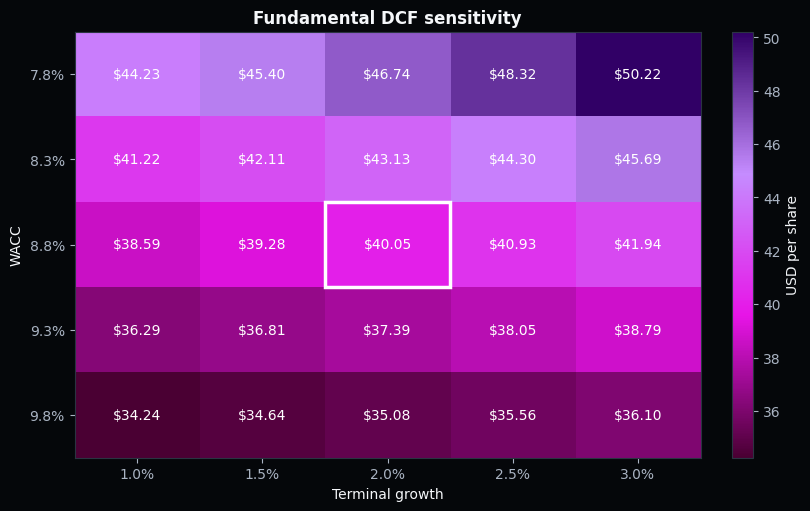

In [56]:
grid = sensitivity.pivot(index='wacc', columns='terminal_growth', values='value_per_share')
dcf_cmap = LinearSegmentedColormap.from_list('dcf_sensitivity', ["#4A0033", "#E714E7", "#C58CFF", "#310066"])
fig_sensitivity, ax = plt.subplots(figsize=(8, 5), layout='constrained')
heat = ax.imshow(grid, cmap=dcf_cmap, aspect='auto')
ax.set_xticks(range(len(grid.columns)), [f'{x:.1%}' for x in grid.columns])
ax.set_yticks(range(len(grid.index)), [f'{x:.1%}' for x in grid.index])

center_i = len(grid.index) // 2
center_j = len(grid.columns) // 2

for i in range(len(grid.index)):
    for j in range(len(grid.columns)):
        ax.text(j, i, f'${grid.iloc[i, j]:.2f}', ha='center', va='center', color='white')
        
        if i == center_i and j == center_j:
            import matplotlib.patches as patches
            rect = patches.Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=2.5, edgecolor='white', facecolor='none', zorder=5)
            ax.add_patch(rect)

ax.set(title='Fundamental DCF sensitivity', xlabel='Terminal growth', ylabel='WACC')
ax.set_facecolor(PANEL_BACKGROUND)
ax.tick_params(colors=MUTED_TEXT)
for spine in ax.spines.values():
    spine.set_color(GRID)
colorbar = fig_sensitivity.colorbar(heat, ax=ax, label='USD per share')
colorbar.ax.tick_params(colors=MUTED_TEXT)
colorbar.set_label('USD per share', color=TEXT)
colorbar.outline.set_edgecolor(GRID)
plt.savefig(output / 'sensitivity.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 57: Visualize forecast economics

**Formula or operation:** Compare scenario revenue and operating-margin paths.

**Why?** The chart reveals the operational recovery the valuation requires. A target price is easier to defend when you can explain the sales and margin path underneath it.

## Step 55A: Plot forecast revenue as a standalone chart

**Why?** Revenue is the first operating assumption in a DCF. Keeping it in its own figure makes the scenario growth path legible without competing scales or a second panel.


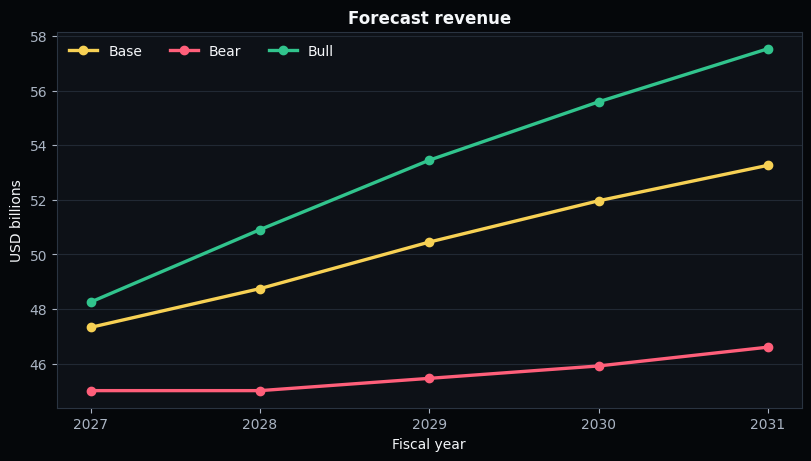

In [57]:
fig_forecast_revenue, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
for name, group in forecast.groupby('case'):
    ax.plot(group.fiscal_year, group.revenue / 1e9, marker='o',
            label=name.title(), color=SCENARIO_COLORS[name], linewidth=2.4)
ax.set(title='Forecast revenue', xlabel='Fiscal year', ylabel='USD billions')
ax.set_xticks(years)
style_axes(ax)
ax.legend(frameon=False, ncol=3)
plt.savefig(output / 'forecast_revenue.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 55B: Plot forecast operating margin as a standalone chart

**Why?** Margin recovery is distinct from top-line growth. A dedicated figure makes the required EBIT progression easier to audit against the revenue case.


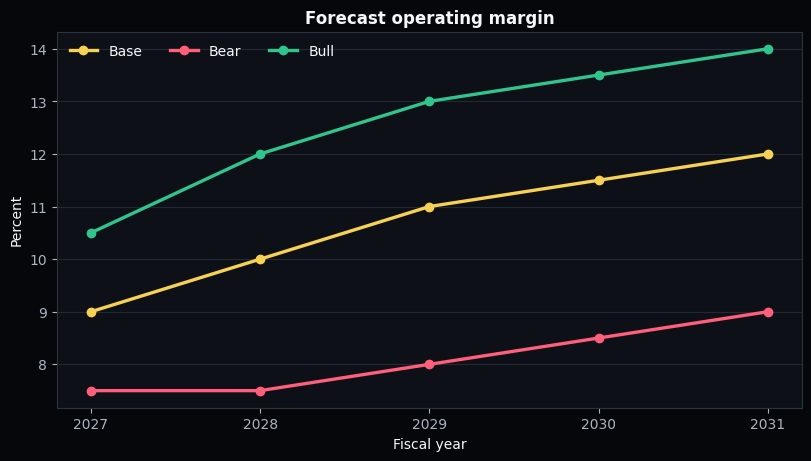

In [58]:
fig_forecast_margin, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
for name, group in forecast.groupby('case'):
    ax.plot(group.fiscal_year, group.margin * 100, marker='o',
            label=name.title(), color=SCENARIO_COLORS[name], linewidth=2.4)
ax.set(title='Forecast operating margin', xlabel='Fiscal year', ylabel='Percent')
ax.set_xticks(years)
style_axes(ax)
ax.legend(frameon=False, ncol=3)
plt.savefig(output / 'forecast_operating_margin.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Sentiment enters only after the fundamental valuation

Sentiment describes the tone of words. It does not measure intrinsic value or the magnitude
of a change in earnings. VADER is a transparent general-language model with a compound
score between -1 and +1; it is not trained specifically to forecast financial returns.
Negation and emphasis rules help, but sarcasm, sporting results, product reviews, and
phrases such as falling costs can mislead it. Search coverage and repeated stories also matter.

> **ASSUMPTION:** Only the latest 90 calendar days inform the final adjustment. Each
> publisher/day contributes one mean score; recent days get a 30-day half-life. The
> maximum adjustment is **2% of the fundamental value**, and at least 10 distinct
> publisher/day observations are required. These are deliberately small analyst policy
> choices, not empirically calibrated price-response coefficients. There is no second
> sentiment change to revenue, margin, WACC or terminal growth.

The final table always shows the fundamental value and the adjusted reference price
separately. The latter is a research overlay and is not a DCF-derived intrinsic value.

## Step 58: Load the five-column news file

**Formula or operation:** Read date, time, source URL, heading and description.

**Why?** Preserve the source schema and use URLs for traceability. Extra scoring fields belong only in derived results.

In [59]:
news_raw = pd.read_csv(root / 'data/raw/news/nike_news.csv', keep_default_na=False)
assert list(news_raw.columns) == ['date', 'time', 'source_url', 'heading', 'description']
news = news_raw.copy()
news['published_at'] = pd.to_datetime(news.date + ' ' + news.time, utc=True, errors='coerce')
unknown_timestamps = int(news.published_at.isna().sum())
news = news.loc[news.published_at.between(analysis_start, cutoff_utc)].copy()
news = news.loc[news.source_url.str.startswith(('https://', 'http://'))].copy()
display(pd.Series({'raw_articles': len(news_raw), 'eligible_articles': len(news),
                   'unparseable_timestamps_excluded': unknown_timestamps}))

raw_articles                       617
eligible_articles                  615
unparseable_timestamps_excluded      0
dtype: int64

## Step 59: Remove repeated articles

**Formula or operation:** Deduplicate by source URL, then by normalized heading.

**Why?** Exact repetitions should not amplify sentiment. Headline deduplication reduces some syndication but cannot identify every paraphrase of the same event.

> **ASSUMPTION:** URL host is a proxy for publisher. Aggregators can host articles from several publishers, so this only partially controls duplicate coverage.

In [60]:
from urllib.parse import urlsplit
news['heading_key'] = news.heading.str.lower().str.replace(r'\W+', ' ', regex=True).str.strip()
news = news.loc[news.heading_key.str.contains(r'(?:^| )(?:nike|nke)(?: |$)', regex=True)].copy()
news = news.sort_values('published_at').drop_duplicates('source_url').drop_duplicates('heading_key')
news['publisher_domain'] = news.source_url.map(lambda url: urlsplit(url).hostname or '')
news['publisher_domain'] = news.publisher_domain.str.removeprefix('www.')
assert news.source_url.is_unique
display(news[['date', 'heading', 'source_url']].tail())

,date,heading,source_url
610,2026-09-08,Nike (NKE) Leaves The S&P 100 As Tech Takes It...,https://simplywall.st/stocks/us/consumer-durab...
611,2026-09-08,$Nike (NKE.US)$,https://www.moomoo.com/community/feed/nike-nke...
612,2026-09-09,Nike (NKE) Dips More Than Broader Market: What...,https://finance.yahoo.com/markets/stocks/artic...
613,2026-09-11,Nike Is Now Down 40% This Year. Is NKE Stock D...,https://247wallst.com/investing/2026/09/11/nik...
614,2026-09-12,Nike (NKE) Launches $NKE Stock Token On Solana,https://simplywall.st/stocks/us/consumer-durab...


## Step 60: Select recent news

**Formula or operation:** Age in days = valuation date - publication date; include ages 0 through 89.

**Why?** Older articles remain available in the archive, but the final overlay reflects recent tone. The timestamp filter has already removed after-close articles.

In [61]:
news['age_days'] = (valuation_date - news.published_at.dt.tz_convert(
    'America/New_York').dt.tz_localize(None).dt.normalize()).dt.days
recent = news.loc[news.age_days.between(0, 89)].copy()
recent['text'] = recent.heading.str.strip() + '. ' + recent.description.str.strip()
display(pd.Series({'recent_articles': len(recent), 'lookback_days': 90}))

recent_articles    36
lookback_days      90
dtype: int64

## Step 61: Score the tone of each article

**Formula or operation:** Article score = VADER compound(heading + description), between -1 and +1.

**Why?** Use the existing heading and search snippet without inventing missing article text. The score measures tone; inspect examples before accepting the final overlay.

In [62]:
analyzer = SentimentIntensityAnalyzer()
recent['sentiment_score'] = recent.text.map(lambda text: analyzer.polarity_scores(text)['compound'])
assert recent.sentiment_score.between(-1, 1).all()
display(recent[['heading', 'description', 'sentiment_score', 'source_url']]
        .sort_values('sentiment_score').head(5))
display(recent[['heading', 'sentiment_score']].sort_values('sentiment_score').tail(5))

,heading,description,sentiment_score,source_url
613,Nike Is Now Down 40% This Year. Is NKE Stock D...,"Nike stock has fallen 40% year to date to $37,...",-0.9022,https://247wallst.com/investing/2026/09/11/nik...
602,"As Nike (NKE) Craters to New Lows, Insiders Ar...","As Nike (NKE) Craters to New Lows, Insiders Ar...",-0.7096,https://finance.yahoo.com/markets/stocks/artic...
586,Nike's latest weak quarter explained in 4 charts,"The only thing Nike (NKE) is ""just doing"" is s...",-0.6705,https://finance.yahoo.com/markets/stocks/artic...
607,What's Wrong With Nike Stock?,Nike (NKE +0.07%) is the largest athletic appa...,-0.4767,https://www.fool.com/investing/2026/09/03/what...
598,"Why Nike Stock Hit a 12-Year Low, Down 78% Fro...","TradingKey - Nike (NKE), which once swept glob...",-0.2732,https://www.tradingkey.com/analysis/stocks/us-...


,heading,sentiment_score
594,Nike (NKE) Stock Faces Margin Slippage As 6.7%...,0.7003
590,Nike Earnings: Transformation Progress Oversha...,0.7783
606,Nike (NKE) Stock Looks Undervalued On Earnings...,0.8047
587,"Nike's turnaround remains a marathon, but Wall...",0.8957
597,Nike downgraded as 'Win Now' will create linge...,0.9022


## Step 62: Balance repeated publisher coverage

**Formula or operation:** Publisher/day score = mean of that publisher's article scores on that date.

**Why?** One prolific domain should not dominate merely because the search returned many headlines from it. Averaging also reduces some duplicated story effects.

In [63]:
recent['publication_day'] = recent.published_at.dt.tz_convert('America/New_York').dt.date
daily = recent.groupby(['publisher_domain', 'publication_day'], as_index=False).agg(
    sentiment_score=('sentiment_score', 'mean'), age_days=('age_days', 'first'),
    article_count=('heading', 'size'))
display(daily.tail())

,publisher_domain,publication_day,sentiment_score,age_days,article_count
31,thestreet.com,2026-09-03,-0.2732,12,1
32,tikr.com,2026-07-01,0.2960,76,1
33,tradingkey.com,2026-08-17,-0.2732,29,1
34,trefis.com,2026-07-14,0.2732,63,1
35,wwd.com,2026-06-30,0.1531,77,1


## Step 63: Weight recent news more heavily

**Formula or operation:** Weight = 0.5^(age_days / 30); S = sum(weight x score) / sum(weight).

**Why?** A 30-day half-life gives a 30-day-old observation half the weight of today's observation. The weighted mean remains bounded by -1 and +1.

> **ASSUMPTION:** With fewer than 10 publisher/day observations, apply a zero adjustment and report insufficient evidence, rather than treating missing news as positive or negative.

In [64]:
daily['weight'] = .5 ** (daily.age_days / 30)
enough_news = len(daily) >= 10
aggregate_sentiment = (float(np.average(daily.sentiment_score, weights=daily.weight))
                       if enough_news else 0.0)
assert -1 <= aggregate_sentiment <= 1
display(pd.Series({'publisher_day_observations': len(daily),
                   'minimum_sample_met': enough_news, 'weighted_sentiment': aggregate_sentiment}))

publisher_day_observations          36
minimum_sample_met                True
weighted_sentiment            0.069881
dtype: object

## Step 64: Convert sentiment to a small final adjustment

**Formula or operation:** Adjustment = clip(0.02 x S, -0.02, +0.02).

**Why?** The multiplier explicitly limits the influence of a noisy text signal. A score of zero leaves the fundamental valuation unchanged.

> **ASSUMPTION:** The 2% multiplier is an uncalibrated research judgement. It does not establish that sentiment causes a 2% return, and it may overlap with information already reflected in forecasts or market prices.

In [65]:
sentiment_cap = .02
sentiment_adjustment = float(np.clip(sentiment_cap * aggregate_sentiment,
                                    -sentiment_cap, sentiment_cap))
assert abs(sentiment_adjustment) <= sentiment_cap
sentiment_summary = pd.DataFrame([{
    'weighted_sentiment': aggregate_sentiment, 'adjustment_fraction': sentiment_adjustment,
    'cap_fraction': sentiment_cap, 'lookback_days': 90, 'half_life_days': 30,
    'publisher_day_count': len(daily), 'minimum_sample_met': enough_news}])
display(sentiment_summary)

,weighted_sentiment,adjustment_fraction,cap_fraction,lookback_days,half_life_days,publisher_day_count,minimum_sample_met
0,0.069881,0.001398,0.02,90,30,36,True


## Step 65: Show the final price comparison

**Formula or operation:** Adjusted reference price = fundamental DCF/share x (1 + sentiment adjustment).

**Why?** Apply the same bounded overlay after valuing each scenario. The fundamental outputs remain unchanged, and the incremental effect is visible in dollars per share.

In [66]:
final_prices = valuation[['fundamental_value_per_share']].copy()
final_prices['sentiment_adjustment_fraction'] = sentiment_adjustment
final_prices['adjusted_reference_price'] = final_prices.fundamental_value_per_share * (1 + sentiment_adjustment)
final_prices['sentiment_effect_per_share'] = (final_prices.adjusted_reference_price -
                                            final_prices.fundamental_value_per_share)
final_prices['comparison_close'] = comparison_price
final_prices['adjusted_upside_vs_close'] = final_prices.adjusted_reference_price / comparison_price - 1
final_prices['valuation_date'] = valuation_date.date().isoformat()
assert np.isfinite(final_prices.select_dtypes('number').to_numpy()).all()
assert np.allclose(final_prices.adjusted_reference_price,
                   valuation.fundamental_value_per_share * (1 + sentiment_adjustment))
display(final_prices)

,fundamental_value_per_share,sentiment_adjustment_fraction,adjusted_reference_price,sentiment_effect_per_share,comparison_close,adjusted_upside_vs_close,valuation_date
case,,,,,,,
bear,25.585500,0.001398,25.621259,0.035759,36.22,-0.292621,2026-09-15
base,40.047320,0.001398,40.103290,0.055971,36.22,0.107214,2026-09-15
bull,52.773915,0.001398,52.847672,0.073757,36.22,0.459074,2026-09-15


## Step 66: Plot fundamental and adjusted prices

**Formula or operation:** Display the dollar effect alongside the unchanged fundamental value.

**Why?** The side-by-side comparison shows whether the modest overlay remains small relative to the variation across operating scenarios.

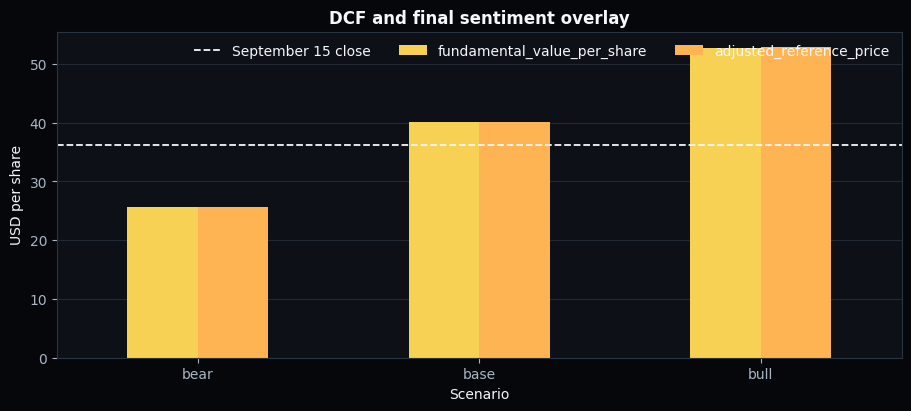

In [67]:
fig_prices, ax = plt.subplots(figsize=(9, 4), layout='constrained')
final_prices[['fundamental_value_per_share', 'adjusted_reference_price']].plot.bar(
    ax=ax, color=[VALUATION_COLORS['fundamental_value'],
                  VALUATION_COLORS['sentiment_value']], rot=0)
ax.axhline(comparison_price, color=VALUATION_COLORS['market_price'],
           linestyle='--', linewidth=1.3, label='September 15 close')
ax.set(title='DCF and final sentiment overlay', ylabel='USD per share', xlabel='Scenario')
style_axes(ax)
ax.legend(frameon=False, ncol=3)
plt.savefig(output / 'price_comparison.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Price target and rating

The target and rating below are model outputs, not external analyst consensus. The range uses the
sentiment-adjusted bear, base and bull DCF values. The base case is the overall price target.
Green and red are reserved for recommendation or positive/negative signals throughout the DCF
visuals; operating scenarios use neutral colors.

## Step 66A: Define the overall target and rating policy

**Formula:** `Target upside = base adjusted price / observed close - 1`.

**Rating rule:** Buy when upside is at least 15%; Sell when downside is at least 15%; otherwise
Hold.

**Why?** A price target and recommendation answer different questions. The target states the
model's estimated value, while the rating translates expected upside or downside into an explicit
policy band.

> **ASSUMPTION:** The plus/minus 15% thresholds are analyst-selected and uncalibrated. The base
> sentiment-adjusted DCF is treated as the overall target as of the valuation date, not as a
> consensus target or guaranteed future trading price. The price-target chart displays a one-year
> horizon for readability; it does not turn the point-in-time DCF value into a timed forecast.

In [68]:
price_target_summary = final_prices[['adjusted_reference_price']].rename(
    columns={'adjusted_reference_price': 'price_target'})
price_target_summary['observed_close'] = comparison_price
price_target_summary['upside'] = price_target_summary.price_target / comparison_price - 1

nke_price_path = root / 'data/raw/prices/nke.csv'
nke_prices = pd.read_csv(nke_price_path, parse_dates=['date'])
nke_prices = nke_prices.loc[nke_prices.date.le(valuation_date)].copy()
assert nke_prices.ticker.eq('NKE').all()
assert nke_prices.adj_close.gt(0).all()
assert np.isclose(nke_prices.iloc[-1].adj_close, comparison_price, atol=.01)
price_window_start = valuation_date - pd.DateOffset(years=1)
nke_price_window = nke_prices.loc[nke_prices.date.ge(price_window_start)].copy()
target_display_date = valuation_date + pd.DateOffset(years=1)
price_target_summary['target_display_date'] = target_display_date.date().isoformat()

buy_threshold = .15
sell_threshold = -.15
overall_target = float(price_target_summary.loc['base', 'price_target'])
overall_upside = float(price_target_summary.loc['base', 'upside'])
overall_rating = ('Buy' if overall_upside >= buy_threshold else
                  'Sell' if overall_upside <= sell_threshold else 'Hold')
rating_summary = pd.DataFrame([{
    'rating': overall_rating, 'overall_price_target': overall_target,
    'observed_close': comparison_price, 'upside': overall_upside,
    'buy_threshold': buy_threshold, 'sell_threshold': sell_threshold,
    'valuation_date': valuation_date.date().isoformat(),
}])
display(rating_summary)


,rating,overall_price_target,observed_close,upside,buy_threshold,sell_threshold,valuation_date
0,Hold,40.10329,36.22,0.107214,0.15,-0.15,2026-09-15


## Step 66B: Plot the overall price-target range

**Formula or operation:** Plot the trailing twelve months of NKE adjusted closes, then extend
dashed paths from the observed close to the adjusted bear, base and bull values at a one-year
display date.

**Why?** The chart gives the target range a market-price context. The base path is labelled
Average, while bear and bull become Low and High.

> **ASSUMPTION:** The one-year date is a visual display convention only. The dashed lines are not
> a forecast of the route that NKE shares will take, nor an event-study estimate.

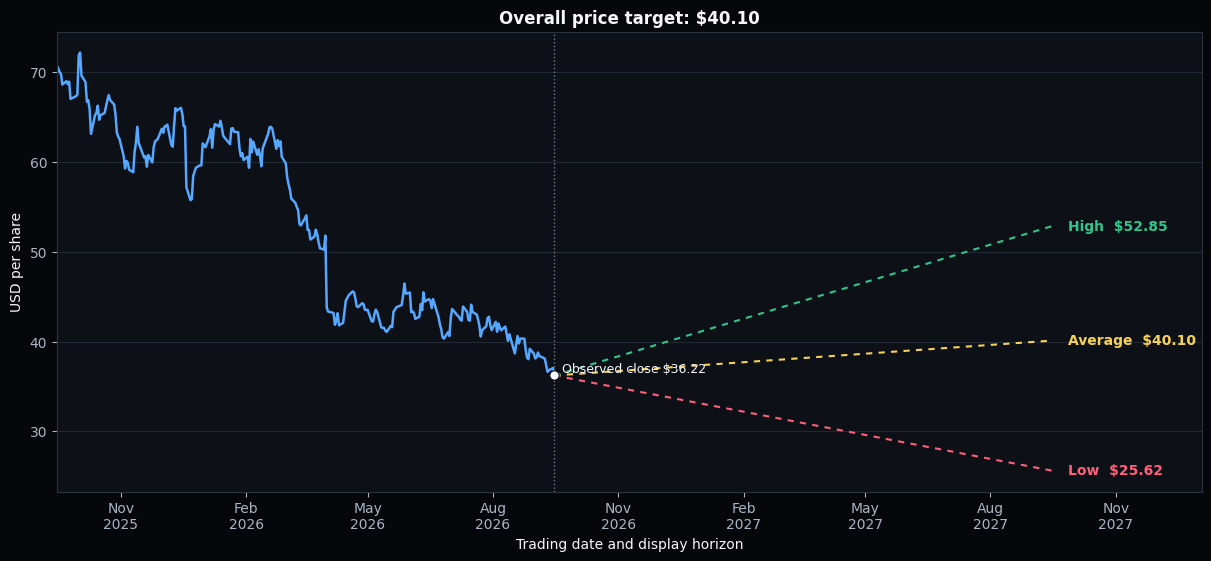

In [69]:
import matplotlib.dates as mdates

fig_price_target, ax = plt.subplots(figsize=(12, 5.5), layout='constrained')
scenario_order = ['bear', 'base', 'bull']
target_values = price_target_summary.loc[scenario_order, 'price_target']
target_labels = {'bear': 'Low', 'base': 'Average', 'bull': 'High'}
ax.plot(nke_price_window.date, nke_price_window.adj_close,
        color=VALUATION_COLORS['historical_revenue'], linewidth=1.8,
        label='NKE adjusted close')
ax.scatter(valuation_date, comparison_price, s=46, color=VALUATION_COLORS['market_price'],
           edgecolor=BACKGROUND, linewidth=.8, zorder=4)
for name in scenario_order:
    value = target_values.loc[name]
    color = SCENARIO_COLORS[name]
    ax.plot([valuation_date, target_display_date], [comparison_price, value],
            color=color, linewidth=1.5, linestyle=(0, (3, 3)))
    ax.annotate(f"{target_labels[name]}  ${value:.2f}",
                xy=(target_display_date, value), xytext=(12, 0),
                textcoords='offset points', color=color, fontsize=10,
                fontweight='bold', va='center', clip_on=False)
ax.axvline(valuation_date, color=REFERENCE, linewidth=1, linestyle=':')
ax.text(valuation_date, comparison_price, f'  Observed close ${comparison_price:.2f}',
        color=TEXT, fontsize=9, va='bottom', ha='left')
ax.set(title=f'Overall price target: ${overall_target:.2f}',
       xlabel='Trading date and display horizon', ylabel='USD per share')
ax.set_xlim(price_window_start, target_display_date + pd.Timedelta(days=110))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
style_axes(ax)
plt.savefig(output / 'overall_price_target.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 66C: Plot the overall rating

**Formula or operation:** Map base-case upside to the Sell, Hold or Buy policy band.

**Why?** A gauge communicates the recommendation separately from the dollar target. The needle
uses continuous upside, while the displayed word follows the threshold rule above.

> **ASSUMPTION:** The gauge clips visual positioning at plus/minus 30% so extreme values remain
> readable. The rating calculation itself is not clipped.

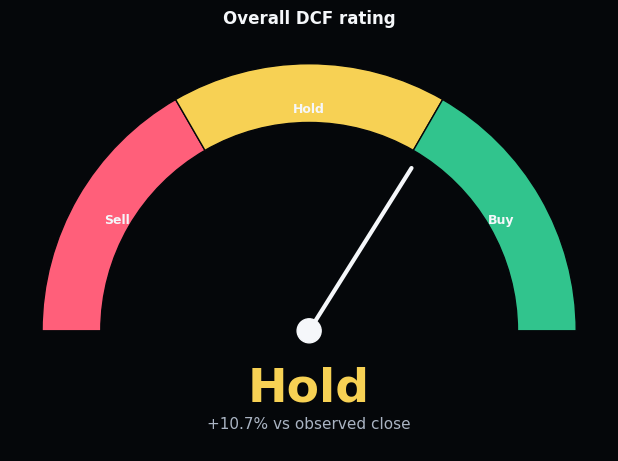

In [70]:
fig_rating, ax = plt.subplots(figsize=(7, 4.5), layout='constrained')
segments = [(120, 180, 'sell', 'Sell'), (60, 120, 'hold', 'Hold'),
            (0, 60, 'buy', 'Buy')]
for start, end, key, label in segments:
    ax.add_patch(Wedge((0, 0), 1, start, end, width=.22,
                       facecolor=SIGNAL_COLORS[key], edgecolor=BACKGROUND))
    angle = np.deg2rad((start + end) / 2)
    ax.text(.83 * np.cos(angle), .83 * np.sin(angle), label,
            ha='center', va='center', color=TEXT, fontsize=9, fontweight='bold')

gauge_upside = np.clip(overall_upside, -.30, .30)
needle_angle = np.deg2rad(180 - (gauge_upside + .30) / .60 * 180)
ax.plot([0, .72 * np.cos(needle_angle)], [0, .72 * np.sin(needle_angle)],
        color=TEXT, linewidth=3, solid_capstyle='round')
ax.add_patch(Circle((0, 0), .045, color=TEXT))
rating_color = SIGNAL_COLORS[overall_rating.lower()]
ax.text(0, -.13, overall_rating, ha='center', va='top',
        color=rating_color, fontsize=34, fontweight='bold')
ax.text(0, -.32, f'{overall_upside:+.1%} vs observed close',
        ha='center', va='top', color=MUTED_TEXT, fontsize=11)
ax.set(title='Overall DCF rating', xlim=(-1.12, 1.12), ylim=(-.45, 1.12), aspect='equal')
ax.set_facecolor(PANEL_BACKGROUND)
ax.axis('off')
plt.savefig(output / 'overall_rating.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Standalone research figures

Each operating, forecast, cash-generation, and valuation figure is produced separately. This preserves legibility in the notebook and lets the static research dashboard reuse exactly the saved output without a composite chart.

## Step 66D: Prepare dashboard views

**Formula or operation:** Select historical operating measures, the base-case cash-flow path,
enterprise-value components and scenario values per share.

**Why?** A good equity-research dashboard connects the target price to the historical evidence,
the operating assumptions required to reach it, and the share of value that depends on the
terminal period.

In [71]:
historical_view = anchors[['period_end', 'revenue', 'gross_margin',
                                   'operating_margin']].copy()
historical_view['fiscal_year'] = historical_view.period_end.dt.year
base_case = forecast.loc[forecast.case.eq('base')].copy()
value_mix = valuation[['pv_explicit', 'pv_terminal', 'terminal_share_of_ev']].copy()
dashboard_prices = final_prices[['fundamental_value_per_share',
                                 'adjusted_reference_price']].copy()
display(pd.Series({'historical_years': len(historical_view),
                   'forecast_years': len(base_case),
                   'scenarios': len(dashboard_prices)}))


historical_years    3
forecast_years      5
scenarios           3
dtype: int64

## Step 66E: Plot historical operating performance

**Formula or operation:** Show reported revenue and the gross- and operating-margin history.

**Why?** Forecasts should be anchored to what Nike has actually earned. Revenue shows scale;
the two margins separate product economics from the operating-cost structure.

## Step 66E: Plot historical revenue as a standalone chart

**Why?** This isolates the revenue base from future assumptions and makes the starting point of the recovery visible.


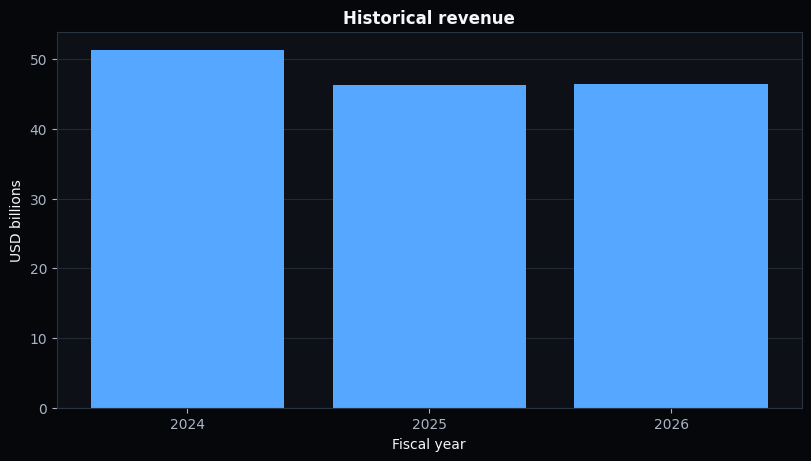

In [72]:
fig_historical_revenue, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.bar(historical_view.fiscal_year, historical_view.revenue / 1e9,
       color=VALUATION_COLORS['historical_revenue'])
ax.set(title='Historical revenue', xlabel='Fiscal year', ylabel='USD billions')
ax.set_xticks(historical_view.fiscal_year)
style_axes(ax)
plt.savefig(output / 'historical_revenue.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 66F: Plot historical margins as a standalone chart

**Why?** Gross and operating margins together show whether the earnings problem is mainly product cost, selling cost, or both.


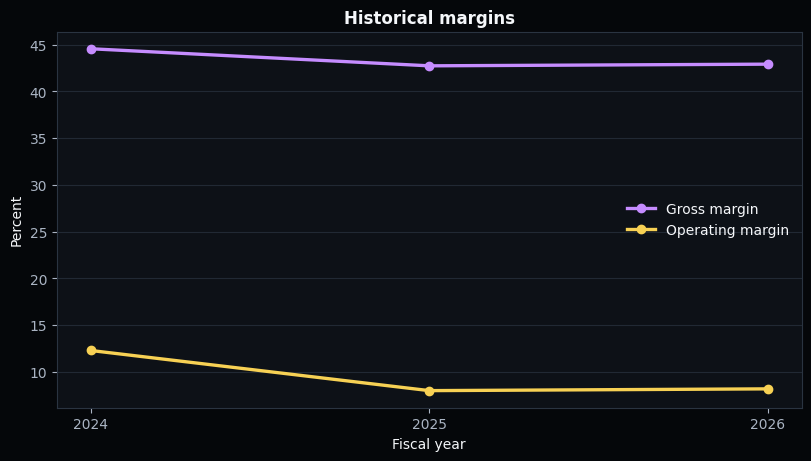

In [73]:
fig_historical_margins, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.plot(historical_view.fiscal_year, historical_view.gross_margin * 100,
        marker='o', linewidth=2.4, label='Gross margin',
        color=VALUATION_COLORS['gross_margin'])
ax.plot(historical_view.fiscal_year, historical_view.operating_margin * 100,
        marker='o', linewidth=2.4, label='Operating margin',
        color=VALUATION_COLORS['operating_margin'])
ax.set(title='Historical margins', xlabel='Fiscal year', ylabel='Percent')
ax.set_xticks(historical_view.fiscal_year)
style_axes(ax)
ax.legend(frameon=False)
plt.savefig(output / 'historical_margins.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 66F: Plot base-case cash generation

**Formula or operation:** Compare stub-adjusted FCFF with its discounted present value for each
forecast year.

**Why?** This reveals both the cash-flow ramp and the value lost to time and risk. A distant cash
flow can be economically important while contributing less present value today.

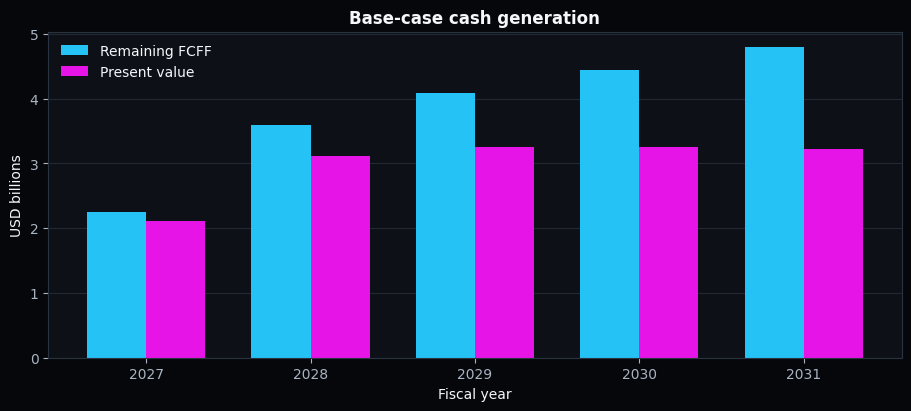

In [74]:
fig_fcff, ax = plt.subplots(figsize=(9, 4), layout='constrained')
x = np.arange(len(base_case))
width = .36
ax.bar(x - width / 2, base_case.fcff_remaining / 1e9, width,
       label='Remaining FCFF', color=VALUATION_COLORS['fcff'])
ax.bar(x + width / 2, base_case.pv_fcff / 1e9, width,
       label='Present value', color=VALUATION_COLORS['pv_fcff'])
ax.set_xticks(x, base_case.fiscal_year)
ax.set(title='Base-case cash generation', xlabel='Fiscal year', ylabel='USD billions')
style_axes(ax)
ax.legend(frameon=False)
plt.savefig(output / 'base_fcff.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 66G: Plot enterprise-value composition

**Formula or operation:** Enterprise value = explicit-period present value + terminal-value
present value.

**Why?** A high terminal share means the conclusion depends heavily on assumptions beyond the
five-year forecast. This is one of the most important DCF risk checks.

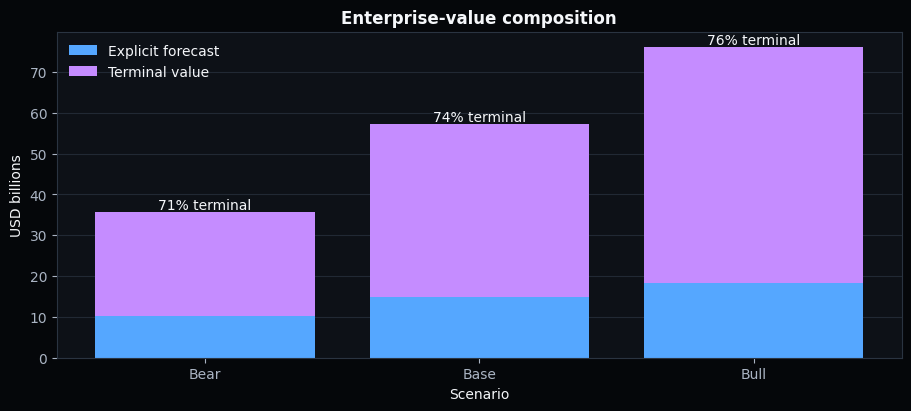

In [75]:
fig_value_mix, ax = plt.subplots(figsize=(9, 4), layout='constrained')
positions = np.arange(len(value_mix))
explicit = value_mix.pv_explicit / 1e9
terminal_pv = value_mix.pv_terminal / 1e9
ax.bar(positions, explicit, label='Explicit forecast',
       color=VALUATION_COLORS['explicit_value'])
ax.bar(positions, terminal_pv, bottom=explicit, label='Terminal value',
       color=VALUATION_COLORS['terminal_value'])
for position, share, total in zip(positions, value_mix.terminal_share_of_ev,
                                  explicit + terminal_pv):
    ax.text(position, total, f'{share:.0%} terminal', ha='center', va='bottom', color=TEXT)
ax.set_xticks(positions, [name.title() for name in value_mix.index])
ax.set(title='Enterprise-value composition', xlabel='Scenario', ylabel='USD billions')
style_axes(ax)
ax.legend(frameon=False)
plt.savefig(output / 'valuation_mix.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 66H: Export a standalone scenario-value figure

**Formula or operation:** Plot the three fundamental values per share against the observed close.

**Why?** The scenario range is an independent valuation output. Keeping it as one chart avoids the visual compression created by a multi-panel dashboard.

## Step 66H: Keep the dashboard as standalone research figures

**Operation:** Do not assemble multiple charts into one figure.

**Why?** Each chart is saved independently so it can be inspected, cited, and placed in the static research dashboard without reducing legibility.


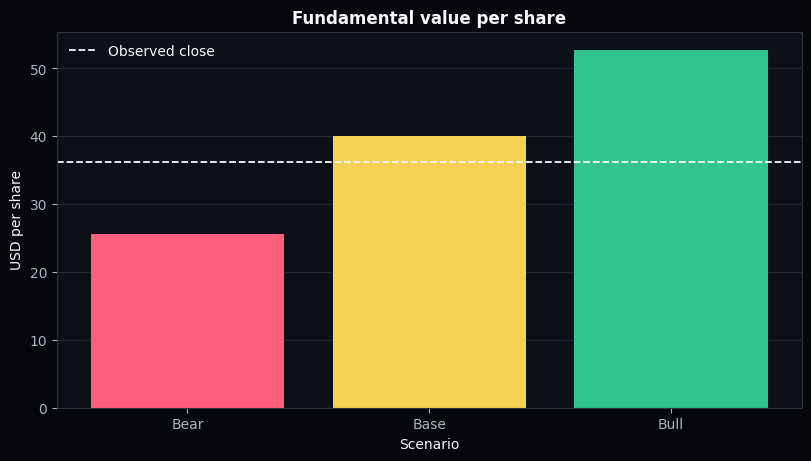

In [76]:
scenario_positions = np.arange(len(dashboard_prices))
fig_fundamental_value, ax = plt.subplots(figsize=(8, 4.5), layout='constrained')
ax.bar(scenario_positions, dashboard_prices.fundamental_value_per_share,
       color=[SCENARIO_COLORS[name] for name in dashboard_prices.index])
ax.axhline(comparison_price, color=VALUATION_COLORS['market_price'],
           linestyle='--', linewidth=1.3, label='Observed close')
ax.set_xticks(scenario_positions, [name.title() for name in dashboard_prices.index])
ax.set(title='Fundamental value per share', xlabel='Scenario', ylabel='USD per share')
style_axes(ax)
ax.legend(frameon=False)
plt.savefig(output / 'fundamental_value_per_share.png', dpi=160, bbox_inches='tight', facecolor=BACKGROUND)
plt.show()


## Step 67: Record the non-statement input ledger

**Formula or operation:** Retain value, date, basis and source for each valuation input.

**Why?** The SEC fact export tracks individual statement values. This table adds market observations and analyst choices that cannot be traced to a financial-statement line.

In [77]:
input_ledger = macro.copy()
additional = pd.DataFrame([
    {'input': 'comparison_price', 'value': comparison_price, 'unit': 'USD/share',
     'observation_date': '2026-09-15', 'source_url': price_source, 'note': 'Recorded project close'},
    {'input': 'debt_fair_value', 'value': debt_value, 'unit': 'USD',
     'observation_date': balance.period_end, 'source_url': balance.source_url,
     'note': f'sec2md debt note line {debt_line}; May value used as proxy'},
    {'input': 'required_operating_cash', 'value': required_operating_cash, 'unit': 'USD',
     'observation_date': '2026-09-15', 'source_url': '', 'note': 'Analyst assumption'},
    {'input': 'sentiment_cap', 'value': sentiment_cap, 'unit': 'fraction',
     'observation_date': '2026-09-15', 'source_url': '', 'note': 'Uncalibrated analyst overlay cap'},
])
input_ledger = pd.concat([input_ledger, additional], ignore_index=True)
display(input_ledger)

,input,value,unit,observation_date,source_url,note
0,risk_free_rate_10y_usd,5.000000e-02,fraction,2026-09-15,https://home.treasury.gov/resource-center/data...,Nominal 10-year Treasury par yield
1,implied_us_equity_risk_premium,4.140000e-02,fraction,2026-09-01,https://pages.stern.nyu.edu/adamodar/New_Home_...,Trailing 12-month adjusted payout estimate
2,shoe_industry_unlevered_beta,9.300000e-01,beta,2026-01,https://pages.stern.nyu.edu/adamodar/New_Home_...,"Damodaran U.S. industry sample, 11 firms; rele..."
3,comparison_price,3.622000e+01,USD/share,2026-09-15,https://finance.yahoo.com/quote/NKE/history/,Recorded project close
4,debt_fair_value,6.800000e+09,USD,2026-05-31,https://www.sec.gov/Archives/edgar/data/320187...,sec2md debt note line 2113; May value used as ...
5,required_operating_cash,0.000000e+00,USD,2026-09-15,,Analyst assumption
6,sentiment_cap,2.000000e-02,fraction,2026-09-15,,Uncalibrated analyst overlay cap


In [78]:
# Save every result directly when this final generation cell is run.
output.mkdir(parents=True, exist_ok=True)

# Tables used by the valuation and audit trail.
anchors.to_csv(output / 'historical_anchors.csv', index=False)
assumptions.to_csv(output / 'assumptions.csv', index=False)
costs.to_csv(output / 'wacc.csv', index=False)
forecast.to_csv(output / 'forecast.csv', index=False)
terminal.to_csv(output / 'terminal_schedule.csv', index=False)
valuation.to_csv(output / 'fundamental_valuation.csv', index=False)
sensitivity.to_csv(output / 'sensitivity.csv', index=False)
recent.to_csv(output / 'sentiment_articles.csv', index=False)
daily.to_csv(output / 'sentiment_publisher_days.csv', index=False)
sentiment_summary.to_csv(output / 'sentiment_summary.csv', index=False)
final_prices.to_csv(output / 'final_prices.csv', index=False)
input_ledger.to_csv(output / 'input_ledger.csv', index=False)
nke_price_window.to_csv(output / 'nke_price_history.csv', index=False)
price_target_summary.to_csv(output / 'price_target_summary.csv', index=False)
rating_summary.to_csv(output / 'rating_summary.csv', index=False)
audit_nike.to_csv(output / 'sec_fact_audit.csv', index=False)

# Charts are saved in their individual generation cells above.

manifest = {'model': 'stepwise_dcf_v2', 'valuation_time': valuation_time.isoformat(),
            'generated_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'approximate_balance_bridge': True,
            'tables': ['historical_anchors', 'assumptions', 'wacc', 'forecast', 'terminal_schedule',
                       'fundamental_valuation', 'sensitivity', 'sentiment_articles',
                       'sentiment_publisher_days', 'sentiment_summary', 'final_prices',
                       'input_ledger', 'nke_price_history', 'price_target_summary',
                       'rating_summary', 'sec_fact_audit']}
(output / 'manifest.json').write_text(json.dumps(manifest, indent=2))
display(pd.Series({'results_directory': str(output)}))


results_directory    /Users/isha/Desktop/Projects/Equity-Research-R...
dtype: object